#  Projet Récapitulatif : Analyse Multimodale de Produits E-Commerce

**Contexte :** Vous êtes Data Scientist pour une plateforme de vente en ligne. Votre manager souhaite savoir si l'on peut prédire automatiquement la **note moyenne (rating)** d'un produit avant même qu'il ne soit mis en ligne, en se basant sur ses caractéristiques.

**Données :** Vous disposez d'un jeu de données contenant :
1.  **Données Structurées :** Prix, Catégorie, Nombre de ventes.
2.  **Données Non-Structurées (Texte) :** Description marketing du produit.
3.  **Données Non-Structurées (Image) :** URL de l'image du produit.

**Objectifs du projet :**
Ce projet va tester l'ensemble de vos compétences acquises durant le semestre :
* **Preprocessing :** Nettoyage, Imputation, Scaling, Encoding.
* **Machine Learning :** Régression Linéaire/Ridge, Validation Croisée.
* **NLP :** Analyse de sentiment ou TF-IDF sur les descriptions.
* **Computer Vision :** Utilisation d'un CNN pré-entraîné (Transfer Learning) pour extraire des features des images.
* **Deep Learning :** Création d'un réseau de neurones (MLP) pour la prédiction finale.
* **Évaluation :** RMSE, R2, Classification (Optionnel).

**Étape 0 : Configuration et Import des Librairies**

In [ ]:
# Installation des dépendances nécessaires (si sur Colab)
!pip install transformers requests pillow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from PIL import Image
from io import BytesIO

# ML Classique
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

# Deep Learning (Keras/TensorFlow)
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image as keras_image

# NLP (Hugging Face)
from transformers import pipeline
import scipy.sparse as sp
import random
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

print("Environnement prêt.")

Environnement prêt.


**Étape 1 : Création/Chargement du Dataset**

*Pour garantir que le projet soit exécutable partout, nous allons générer un dataset réaliste simulant des produits.*

In [ ]:
# Simulation de données réalistes
data = {
    'titre': [
        'Smartphone X Pro', 'Jean Slim Bleu', 'Cafetière Express', 'Roman Policier', 'Casque Audio Sans Fil',
        'Montre Connectée', 'T-shirt Coton Bio', 'Blender Puissant', 'Guide de Voyage', 'Tablette Graphique'
    ] * 10, # On duplique pour avoir 100 lignes pour l'exercice
    'categorie': ['High-Tech', 'Mode', 'Maison', 'Livres', 'High-Tech', 'High-Tech', 'Mode', 'Maison', 'Livres', 'High-Tech'] * 10,
    'prix': [999.99, 49.50, 120.00, 15.90, 199.99, 250.00, 25.00, 80.00, 22.00, 350.00] * 10,
    'nb_ventes': [1500, 5000, 300, 10000, 800, 1200, 6000, 450, 3000, 150] * 10,
    'description': [
        "Un téléphone incroyable avec une batterie révolutionnaire.",
        "Jean confortable mais la couleur déteint au lavage. Déçu.",
        "Fait un excellent café, facile à nettoyer. Je recommande.",
        "Une histoire captivante du début à la fin.",
        "Le son est bon mais le bluetooth se déconnecte souvent. Moyen.",
        "Superbe montre, suivi précis et design élégant.",
        "Tissu trop fin, se déchire vite. Mauvaise qualité.",
        "Mixe tout en quelques secondes, très puissant !",
        "Informations obsolètes, ne pas acheter.",
        "Parfait pour les dessinateurs, très précise."
    ] * 10,
    # URLs d'images génériques (Unsplash)
    'image_url': [
        'https://images.unsplash.com/photo-1511707171634-5f897ff02aa9?w=200', # Phone
        'https://images.unsplash.com/photo-1542272454315-4c01d7abdf4a?w=200', # Jeans
        'https://images.unsplash.com/photo-1517668808822-9ebb02f2a0e6?w=200', # Coffee
        'https://images.unsplash.com/photo-1544947950-fa07a98d237f?w=200', # Book
        'https://images.unsplash.com/photo-1505740420928-5e560c06d30e?w=200', # Headphones
        'https://images.unsplash.com/photo-1523275335684-37898b6baf30?w=200', # Watch
        'https://images.unsplash.com/photo-1521572163474-6864f9cf17ab?w=200', # Tshirt
        'https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200', # Blender
        'https://images.unsplash.com/photo-1589829085413-56de8ae18c73?w=200', # Guide
        'https://images.unsplash.com/photo-1585076641399-5c06d1b3365f?w=200'  # Tablet
    ] * 10,
    'note': [4.8, 2.5, 4.5, 4.9, 3.0, 4.7, 2.0, 4.6, 1.5, 4.8] * 10 # CIBLE
}

# Ajout de bruit aléatoire pour rendre la régression moins parfaite
df = pd.DataFrame(data)
df['prix'] = df['prix'] + np.random.normal(0, 5, 100)
df['note'] = df['note'] + np.random.normal(0, 0.2, 100)
df['note'] = df['note'].clip(0, 5) # Garder entre 0 et 5

# Introduction de valeurs manquantes pour l'exercice
df.loc[0:5, 'prix'] = np.nan

print("Aperçu des données :")
display(df.head())
df.info()

Aperçu des données :


,titre,categorie,prix,nb_ventes,description,image_url,note
0,Smartphone X Pro,High-Tech,NaN,1500,Un téléphone incroyable avec une batterie révo...,https://images.unsplash.com/photo-151170717163...,4.516926
1,Jean Slim Bleu,Mode,NaN,5000,Jean confortable mais la couleur déteint au la...,https://images.unsplash.com/photo-154227245431...,2.415871
2,Cafetière Express,Maison,NaN,300,"Fait un excellent café, facile à nettoyer. Je ...",https://images.unsplash.com/photo-151766880882...,4.431457
3,Roman Policier,Livres,NaN,10000,Une histoire captivante du début à la fin.,https://images.unsplash.com/photo-1544947950-f...,4.739545
4,Casque Audio Sans Fil,High-Tech,NaN,800,Le son est bon mais le bluetooth se déconnecte...,https://images.unsplash.com/photo-150574042092...,2.967743


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   titre        100 non-null    object 
 1   categorie    100 non-null    object 
 2   prix         94 non-null     float64
 3   nb_ventes    100 non-null    int64  
 4   description  100 non-null    object 
 5   image_url    100 non-null    object 
 6   note         100 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 5.6+ KB


**Étape 2 : Analyse et Preprocessing (Données Tabulaires)**

*Mission : Préparez les données structurées (prix, nb_ventes, categorie) pour le modèle.*

In [ ]:
# Séparation Features (X) / Cible (y) pour la baseline tabulaire
y = df['note'].values                                                   # La variable cible : le vecteur des notes (y)
X_tab = df.drop(['note', 'titre', 'description', 'image_url'], axis=1)  # Les features tabulaires : on enlève la cible et les colonnes non structurées

numeric_features = ['prix', 'nb_ventes']                                # Liste des variables numériques à prétraiter
categorical_features = ['categorie']                                    # Liste des variables catégorielles à encoder

numeric_transformer = Pipeline(steps=[                                  # Pipeline de preprocessing pour les variables numériques
    ('imputer', SimpleImputer(strategy='median')),                      # 1) Imputation des valeurs manquantes par la médiane
    ('scaler', StandardScaler())                                        # 2) Standardisation (moyenne 0, variance 1)
])

categorical_transformer = Pipeline(steps=[                              # Pipeline de preprocessing pour les variables catégorielles
    ('imputer', SimpleImputer(strategy='most_frequent')),               # 1) Imputation des valeurs manquantes par la modalité la plus fréquente
    ('onehot', OneHotEncoder(handle_unknown='ignore'))                  # 2) Encodage One-Hot des catégories (en vecteurs binaires)
])

preprocessor = ColumnTransformer(                                       # Combinaison des deux pipelines dans un seul transformateur
    transformers=[
        ('num', numeric_transformer, numeric_features),                 # Appliquer numeric_transformer aux colonnes numériques
        ('cat', categorical_transformer, categorical_features)          # Appliquer categorical_transformer aux colonnes catégorielles
    ]
)

# Test du preprocessor
X_tab_preprocessed = preprocessor.fit_transform(X_tab)                  # On ajuste (fit) et transforme les features tabulaires X_tab
print("Shape des features tabulaires après preprocessing :",            # On affiche la taille de la matrice transformée
      X_tab_preprocessed.shape)


Shape des features tabulaires après preprocessing : (100, 6)


**Étape 3 : Baseline (Régression sur données structurées)**

*Mission : Entraînez un modèle simple pour avoir un point de comparaison.*

In [ ]:


X_train_tab, X_test_tab, y_train_tab, y_test_tab = train_test_split(   # On divise les données en train et test
    X_tab, y, test_size=0.2, random_state=42                           # 20% pour le test, random_state pour reproductibilité
)

baseline_model = Ridge(alpha=1.0)                                      # Modèle de régression Ridge avec régularisation L2

baseline_pipeline = Pipeline(steps=[                                   # Pipeline : enchaînement preprocessing + modèle
    ('preprocess', preprocessor),                                      # Étape 1 : appliquer le preprocessing (imputation, scaling, encodage)
    ('model', baseline_model)                                          # Étape 2 : entraîner le modèle Ridge
])

baseline_pipeline.fit(X_train_tab, y_train_tab)                        # Entraînement du pipeline complet sur les données d'entraînement

y_pred_baseline = baseline_pipeline.predict(X_test_tab)                # Prédictions du modèle sur les données de test

rmse_baseline = np.sqrt(mean_squared_error(y_test_tab, y_pred_baseline))  # Calcul du RMSE : erreur moyenne quadratique
r2_baseline = r2_score(y_test_tab, y_pred_baseline)                       # Calcul du score R² : qualité d’ajustement du modèle

print("\n--- Baseline Results (Ridge sur données tabulaires) ---")     # Affichage du titre des résultats
print(f"RMSE: {rmse_baseline:.4f}")                                    # Affichage du RMSE avec 4 décimales
print(f"R2  : {r2_baseline:.4f}")                                      # Affichage du score R² avec 4 décimales



--- Baseline Results (Ridge sur données tabulaires) ---
RMSE: 0.6229
R2  : 0.6421


**Étape 4 : NLP (Analyse de Sentiment sur les descriptions)**

*Les descriptions contiennent des avis implicites ("déçu", "incroyable"). Nous allons extraire un score de sentiment pour l'utiliser comme feature supplémentaire.*

*Mission : Utilisez un modèle pré-entraîné Hugging Face pour analyser les descriptions.*

In [ ]:


print("\nChargement du pipeline d'analyse de sentiment (modèle multilingue)...")  # Message d'information pour l'utilisateur

sentiment_analyzer = pipeline(                                                   # Création d'un pipeline Hugging Face
    "sentiment-analysis",                                                        # Tâche : analyse de sentiment
    model="nlptown/bert-base-multilingual-uncased-sentiment"                     # Modèle multilingue pré-entraîné (1 à 5 étoiles)
)

def compute_sentiment_score(text):                                               # Fonction pour convertir une description en score numérique
    """
    Convertit la sortie '1 star' ... '5 stars' en score numérique [-1, 1].
    1 star -> -1, 3 stars -> 0, 5 stars -> +1
    """
    if not isinstance(text, str) or text.strip() == "":                          # Si le texte est vide ou non valide
        return 0.0                                                               # On retourne un score neutre (0)
    try:
        result = sentiment_analyzer(text[:512])[0]                               # On appelle le modèle sur les 512 premiers caractères
        label = result['label']                                                  # Exemple : "4 stars"
        stars = int(label[0])                                                    # On récupère le chiffre du début (1, 2, 3, 4, 5)
        score = (stars - 3) / 2.0                                                # Transformation en intervalle [-1, 1]
        return score                                                             # On retourne le score final
    except Exception as e:                                                       # En cas d'erreur (API, texte étrange, etc.)
        print(f"Erreur sentiment pour texte '{text[:30]}...' : {e}")             # On affiche un message d'erreur
        return 0.0                                                               # On retourne un score neutre par sécurité

print("Calcul des scores de sentiment...")                                       # Message pour signaler le début du calcul

df['sentiment_score'] = df['description'].apply(compute_sentiment_score)         # On applique la fonction à chaque description du dataset

print("\nAperçu des colonnes avec sentiment :")                                  # Affichage d'un aperçu des résultats
display(df[['description', 'sentiment_score']].head())                           # On montre les premières lignes (texte + score)



Chargement du pipeline d'analyse de sentiment (modèle multilingue)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


Calcul des scores de sentiment...

Aperçu des colonnes avec sentiment :


,description,sentiment_score
0,Un téléphone incroyable avec une batterie révo...,1.0
1,Jean confortable mais la couleur déteint au la...,-0.5
2,"Fait un excellent café, facile à nettoyer. Je ...",1.0
3,Une histoire captivante du début à la fin.,1.0
4,Le son est bon mais le bluetooth se déconnecte...,0.0


**Étape 5 : Computer Vision (Extraction de Features)**


*Nous allons utiliser le Transfer Learning. Un modèle ResNet50 (entraîné sur ImageNet) va regarder les images des produits et nous donner un vecteur de caractéristiques numériques.*

*Mission : Créez une fonction qui télécharge l'image et la transforme en vecteur via ResNet50.*

In [ ]:

print("\nChargement du modèle ResNet50 (ImageNet, include_top=False)...")        # Information : chargement du modèle de vision

base_model_cv = ResNet50(weights='imagenet', include_top=False, pooling='avg')   # Modèle ResNet50 pré-entraîné sans la couche finale (features globales)

def extract_image_features(img_url):                                             # Fonction pour extraire un vecteur de features à partir d'une URL d'image
    try:
        # 1. Télécharger l'image
        response = requests.get(img_url, timeout=10)                             # Requête HTTP vers l'URL de l'image
        response.raise_for_status()                                              # Vérifie que le téléchargement s'est bien passé
        img = Image.open(BytesIO(response.content)).convert("RGB")              # Ouvre l'image en mémoire et la convertit en RGB

        # 2. Redimensionner pour ResNet (224x224)
        img = img.resize((224, 224))                                             # Redimensionne l'image à 224x224 pixels

        # 3. Convertir en array et préprocesser
        x = keras_image.img_to_array(img)                                        # Convertit l'image PIL en tableau NumPy
        x = np.expand_dims(x, axis=0)                                            # Ajoute une dimension batch (1, 224, 224, 3)
        x = preprocess_input(x)                                                  # Applique le préprocessing spécifique à ResNet50

        # 4. Extraire les features
        features = base_model_cv.predict(x, verbose=0)                           # Passe l'image dans ResNet50 pour obtenir les features
        return features.flatten()                                                # Aplati le vecteur (ex : (2048,) )

    except Exception as e:                                                       # Si une erreur survient (URL invalide, timeout, etc.)
        print(f"Erreur image: {e}")                                              # Affiche l'erreur pour debug
        return np.zeros(2048, dtype=float)                                       # Retourne un vecteur de 0 comme valeur par défaut

print("Extraction des features images (sur tout le dataset)...")                 # Message pour indiquer le début du traitement

image_features_list = df['image_url'].apply(extract_image_features).values       # Applique la fonction à chaque URL du DataFrame
image_features = np.vstack(image_features_list)                                  # Empile tous les vecteurs en une matrice (N, 2048)

print("Shape des features images :", image_features.shape)                       # Affiche la forme finale des features d'image

img_features_df = pd.DataFrame(                                                  # Convertit les features en DataFrame pour manipulation plus simple
    image_features,
    index=df.index,
    columns=[f'img_feat_{i}' for i in range(image_features.shape[1])]            # Nomme les colonnes img_feat_0, img_feat_1, ...
)



Chargement du modèle ResNet50 (ImageNet, include_top=False)...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Extraction des features images (sur tout le dataset)...
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Erreur image: 404 Client Error: Not Found for url: https://images.unsplash.com/photo-1570222094114-28a9d8896b74?w=200
Err

**Étape 6 : Modèle Final "Multi-Modal" (Deep Learning)**

*C'est l'étape finale. Nous allons combiner :*

*Les features tabulaires traitées.*
*Le score de sentiment (NLP).*
*(Optionnel) Les vecteurs d'images.*
*Pour simplifier l'exécution ici, nous allons construire un MLP qui prend en entrée les données tabulaires + le score de sentiment. *texte en italique*

*Mission : Construire un réseau de neurones avec Keras.*

In [ ]:


print("\nPréparation des données multimodales pour le MLP...")                   # Message d'information

# 1) Re-préparer les features tabulaires sur tout le dataset
X_tab_all = df[['prix', 'nb_ventes', 'categorie']]                               # On sélectionne les colonnes tabulaires utiles

X_tab_all_preprocessed = preprocessor.fit_transform(X_tab_all)                   # On applique le préprocesseur (imputation + encodage + scaling)

if sp.issparse(X_tab_all_preprocessed):                                          # Si la sortie est une matrice sparse (OneHotEncoder)
    X_tab_all_preprocessed = X_tab_all_preprocessed.toarray()                    # On la convertit en array dense NumPy

# 2) Sentiment sous forme de colonne (N, 1)
sentiment_array = df['sentiment_score'].values.reshape(-1, 1)                    # On met le score de sentiment en colonne (N, 1)

# 3) Concaténation : tabulaire + sentiment + images
X_multimodal = np.hstack([X_tab_all_preprocessed, sentiment_array, image_features])  # Fusion de toutes les features en une seule matrice
y_multimodal = df['note'].values                                                 # La cible reste la note du produit

print("Shape X_multimodal :", X_multimodal.shape)                                # Affiche la taille de la matrice d'entrée (N, nb_features)
print("Shape y_multimodal :", y_multimodal.shape)                                # Affiche la taille du vecteur cible (N,)

# Split Train/Test
X_train_mm, X_test_mm, y_train_mm, y_test_mm = train_test_split(                 # Division en train/test pour le modèle multimodal
    X_multimodal, y_multimodal, test_size=0.2, random_state=42                   # 20% pour le test, seed pour reproductibilité
)

# Scaling pour le MLP
scaler_mlp = StandardScaler()                                                    # Standardisation des features pour le MLP
X_train_mm_scaled = scaler_mlp.fit_transform(X_train_mm)                         # Fit + transform sur les données d'entraînement
X_test_mm_scaled = scaler_mlp.transform(X_test_mm)                               # Transform uniquement sur les données de test

# --- Construction du MLP ---

input_dim = X_train_mm_scaled.shape[1]                                           # Nombre de features en entrée du réseau
print("Dimension d'entrée du MLP :", input_dim)                                  # Affiche la dimension pour contrôle

model_mlp = Sequential([                                                         # Définition du modèle séquentiel Keras
    Dense(128, activation='relu', input_shape=(input_dim,)),                     # Première couche dense avec 128 neurones + ReLU
    BatchNormalization(),                                                        # Normalisation de batch pour stabiliser l'entraînement
    Dropout(0.3),                                                                # Dropout à 30% pour éviter le surapprentissage
    Dense(64, activation='relu'),                                                # Deuxième couche dense avec 64 neurones + ReLU
    BatchNormalization(),                                                        # Normalisation supplémentaire
    Dropout(0.3),                                                                # Dropout à nouveau
    Dense(1, activation='linear')                                                # Couche de sortie : 1 neurone (régression)
])

model_mlp.compile(                                                               # Compilation du modèle
    optimizer=Adam(learning_rate=1e-3),                                          # Optimiseur Adam avec un petit learning rate
    loss='mse',                                                                  # Fonction de perte : Mean Squared Error (régression)
    metrics=['mae']                                                              # Métrique suivie : Mean Absolute Error
)

model_mlp.summary()                                                              # Affiche le résumé de l’architecture du modèle

# --- Entraînement ---

history = model_mlp.fit(                                                         # Lancement de l'entraînement
    X_train_mm_scaled, y_train_mm,                                               # Données d'entraînement
    validation_split=0.2,                                                        # 20% des données d'entraînement pour la validation
    epochs=50,                                                                   # Nombre d'époques
    batch_size=16,                                                               # Taille de batch
    verbose=1                                                                    # Affichage détaillé de l'entraînement
)

# --- Évaluation finale ---

y_pred_mm = model_mlp.predict(X_test_mm_scaled).ravel()                          # Prédictions du MLP sur le set de test (aplaties en 1D)

rmse_mm = np.sqrt(mean_squared_error(y_test_mm, y_pred_mm))                      # Calcul du RMSE pour le modèle multimodal
r2_mm = r2_score(y_test_mm, y_pred_mm)                                           # Calcul du score R²

print("\n=== Résultats Modèle Multimodal (MLP) ===")                             # Titre des résultats
print(f"RMSE: {rmse_mm:.4f}")                                                    # RMSE avec 4 décimales
print(f"R2  : {r2_mm:.4f}")                                                      # R² avec 4 décimales

print("\n=== Comparaison Baseline vs Multimodal ===")                            # Comparaison entre les deux modèles
print(f"Baseline Ridge  -> RMSE: {rmse_baseline:.4f} | R2: {r2_baseline:.4f}")   # Résultats du modèle Ridge (baseline)
print(f"MLP Multimodal  -> RMSE: {rmse_mm:.4f} | R2: {r2_mm:.4f}")               # Résultats du modèle multimodal




Préparation des données multimodales pour le MLP...
Shape X_multimodal : (100, 2055)
Shape y_multimodal : (100,)
Dimension d'entrée du MLP : 2055


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,257 (1.04 MB)

 Trainable params: 271,873 (1.04 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - loss: 17.0193 - mae: 3.5381 - val_loss: 18.3930 - val_mae: 4.1162
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 15.9922 - mae: 3.6166 - val_loss: 13.5938 - val_mae: 3.5565
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 14.4851 - mae: 3.5969 - val_loss: 14.5559 - val_mae: 3.6494
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 14.2844 - mae: 3.5043 - val_loss: 15.1357 - val_mae: 3.6287
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 13.3901 - mae: 3.3873 - val_loss: 14.7315 - val_mae: 3.5319
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 13.2392 - mae: 3.4508 - val_loss: 14.4332 - val_mae: 3.4846
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 13.5660 - mae: 3.4025 - val_loss: 14.1636 - val_mae: 3.4419
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 13.5514 - mae: 3.4310 - val_loss: 12.5061 - val_mae: 3.1937
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 11.3959

**Visualisation de l'entraînement**

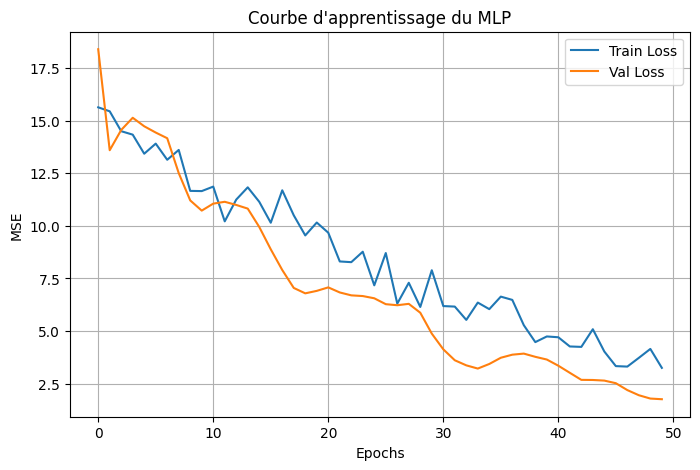

In [ ]:


plt.figure(figsize=(8, 5))                                                       # Définition de la taille de la figure
plt.plot(history.history['loss'], label='Train Loss')                            # Courbe de la perte sur le train
plt.plot(history.history['val_loss'], label='Val Loss')                          # Courbe de la perte sur la validation
plt.title("Courbe d'apprentissage du MLP")                                       # Titre du graphique
plt.ylabel('MSE')                                                                # Label axe Y
plt.xlabel('Epochs')                                                             # Label axe X
plt.legend()                                                                     # Affichage de la légende
plt.grid(True)                                                                   # Grille pour mieux lire la courbe
plt.show()                                                                       # Affichage final du graphique
